In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

In [2]:
datos, metadatos = tfds.load('cats_vs_dogs', as_supervised=True, with_info=True)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.EITUYK_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [3]:
metadatos

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

,image,label
0,,1 (dog)
1,,1 (dog)
2,,1 (dog)
3,,0 (cat)
4,,1 (dog)
5,,1 (dog)
6,,0 (cat)
7,,0 (cat)
8,,1 (dog)
9,,1 (dog)

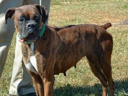
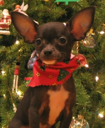
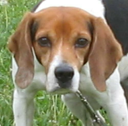
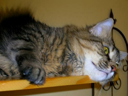
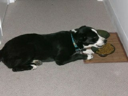
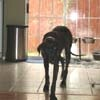
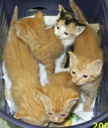
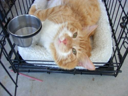
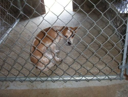
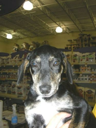

In [4]:
tfds.as_dataframe(datos['train'].take(10), metadatos)

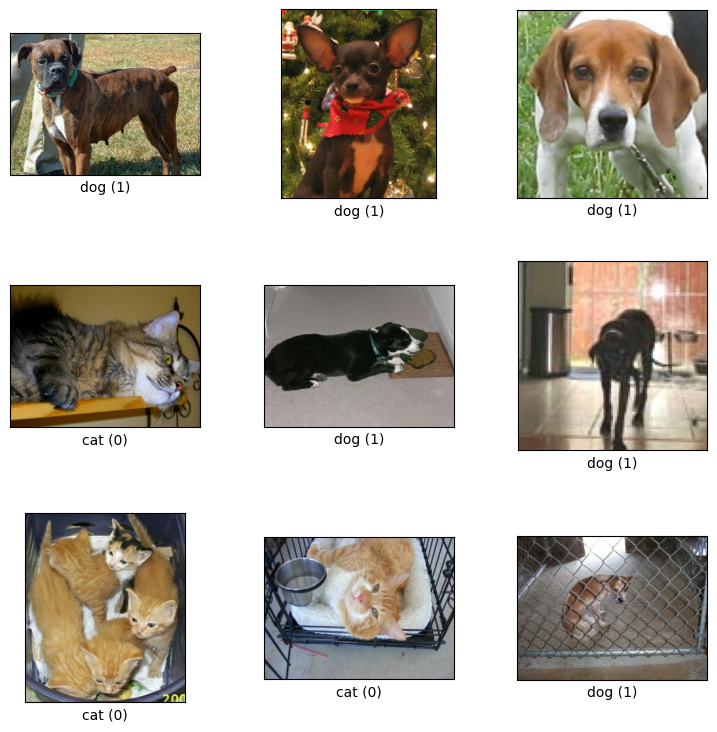

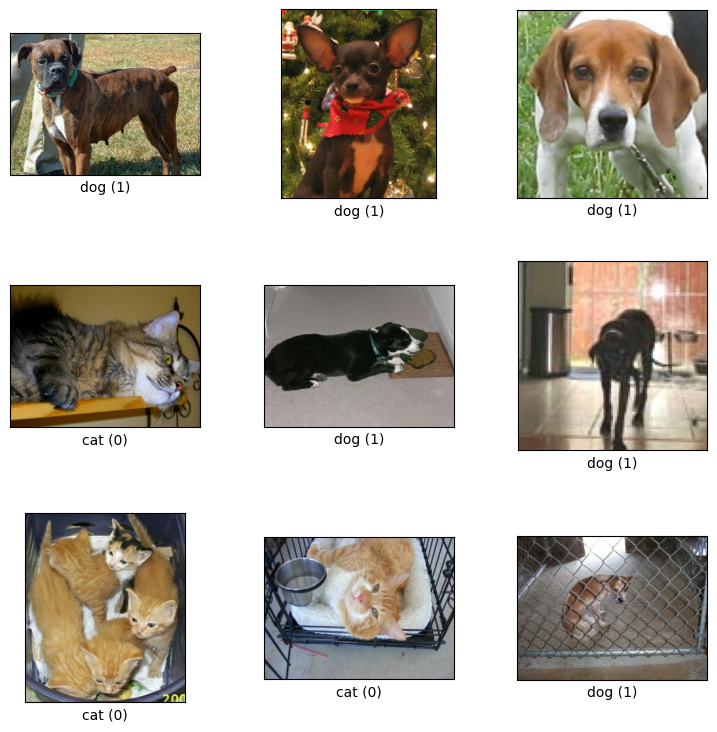

In [5]:
tfds.show_examples(datos['train'], metadatos)

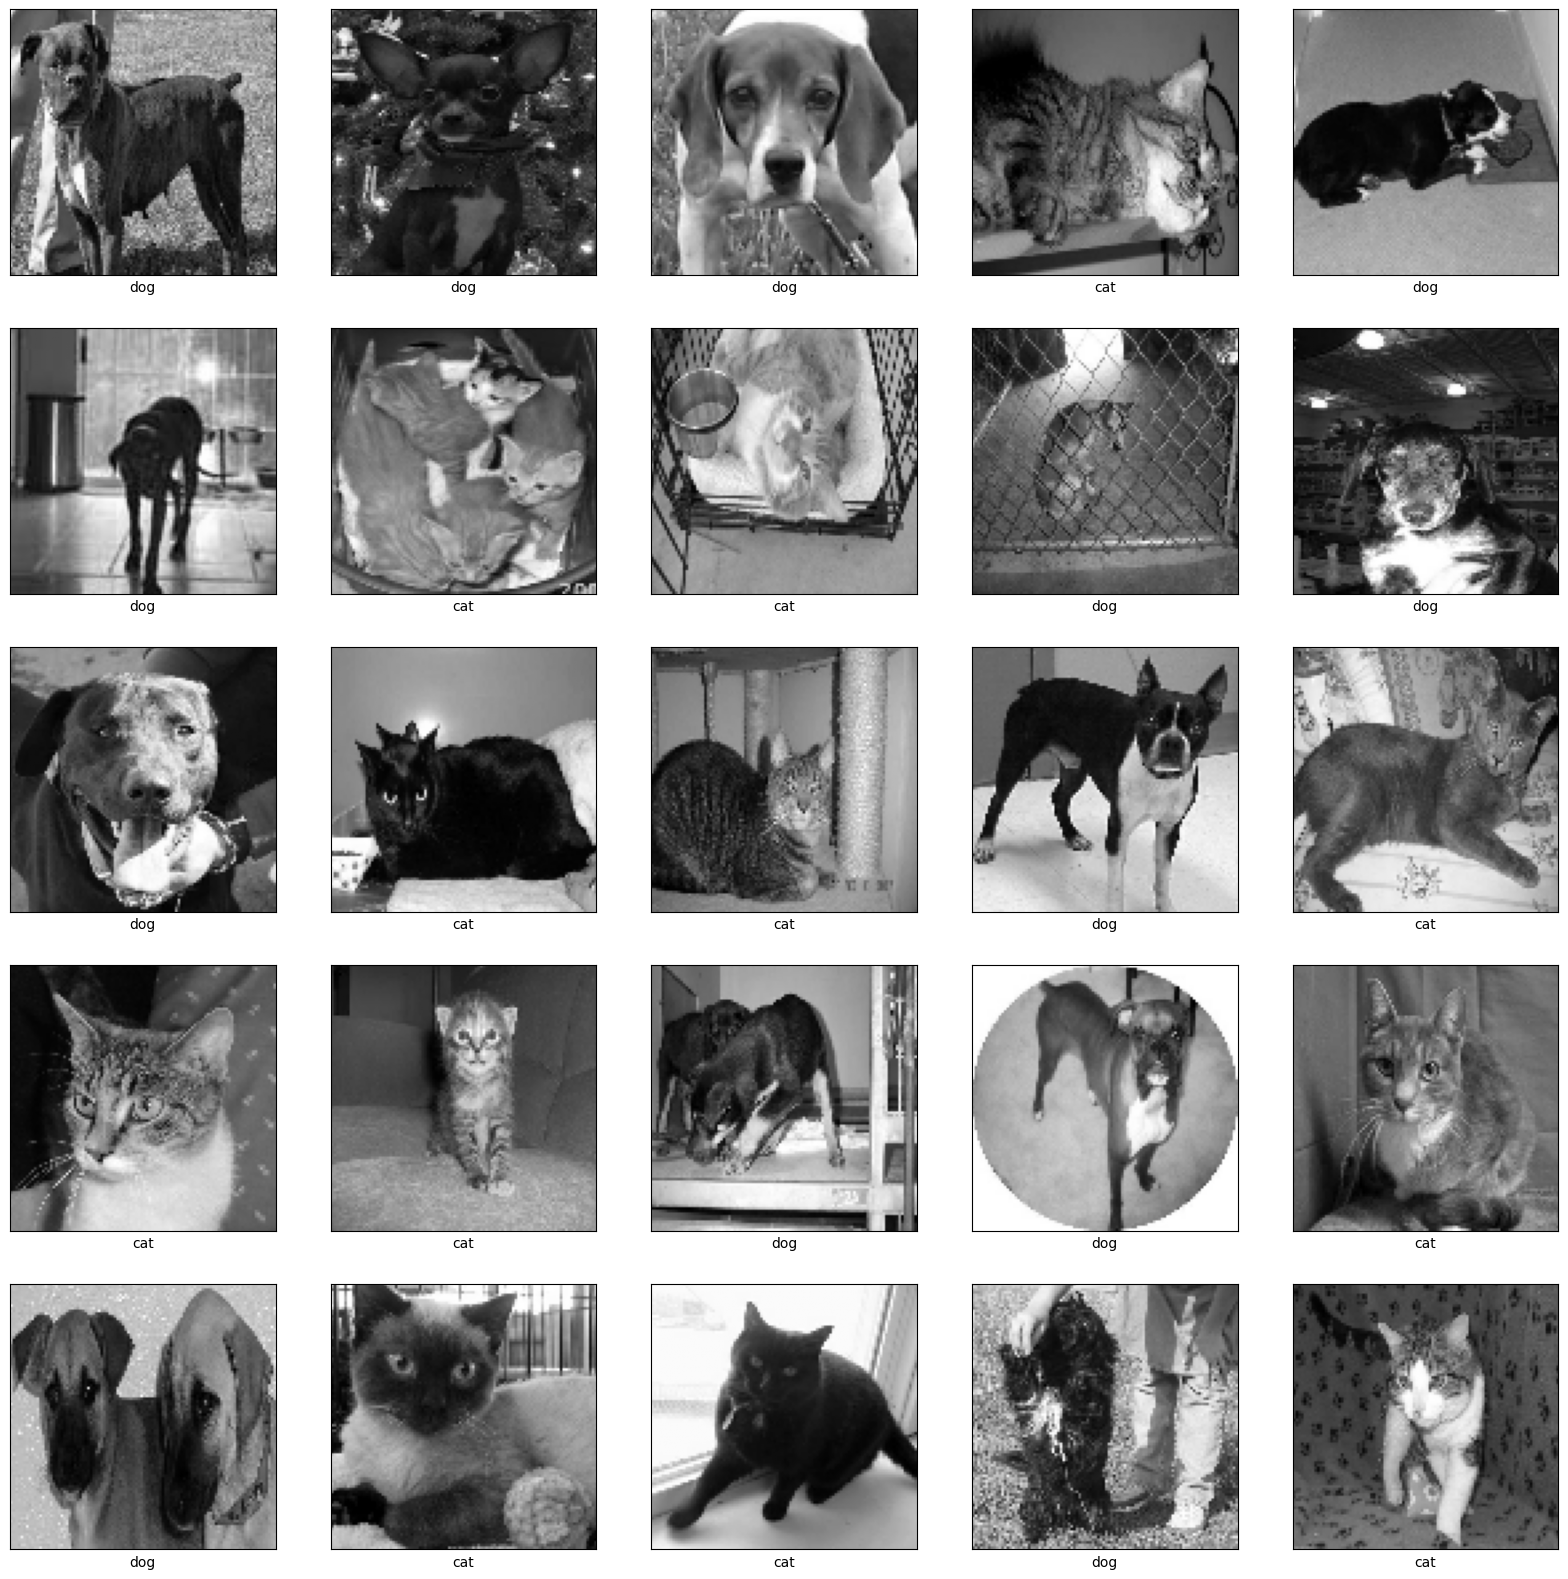

In [6]:
import matplotlib.pyplot as plt
import cv2
plt.figure(figsize=(20, 20))
Tamaño_imagen = 100
for i,(imagen, etiqueta) in enumerate(datos['train'].take(25)):
   imagen = cv2.resize(imagen.numpy(), (Tamaño_imagen, Tamaño_imagen))
   imagen  = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
   plt.subplot(5, 5, i+1)
   plt.xticks([])
   plt.yticks([])
   plt.imshow(imagen, cmap='gray')
   plt.xlabel(metadatos.features['label'].names[etiqueta])
plt.show()



In [7]:
datos_entrenamiento=[]

In [8]:
for i, (imagen, etiqueta) in enumerate(datos['train']):
   imagen = cv2.resize(imagen.numpy(), (Tamaño_imagen, Tamaño_imagen))
   imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
   imagen = imagen.reshape(Tamaño_imagen, Tamaño_imagen, 1)
   datos_entrenamiento.append([imagen,etiqueta])

In [9]:
datos_entrenamiento[0]

[array([[[249],
         [190],
         [105],
         ...,
         [189],
         [196],
         [143]],
 
        [[232],
         [127],
         [ 88],
         ...,
         [187],
         [180],
         [186]],
 
        [[171],
         [ 87],
         [ 83],
         ...,
         [129],
         [158],
         [166]],
 
        ...,
 
        [[113],
         [173],
         [162],
         ...,
         [143],
         [156],
         [119]],
 
        [[140],
         [152],
         [171],
         ...,
         [ 98],
         [155],
         [154]],
 
        [[ 91],
         [109],
         [167],
         ...,
         [ 46],
         [ 51],
         [ 47]]], dtype=uint8),
 <tf.Tensor: shape=(), dtype=int64, numpy=1>]

In [10]:
len(datos_entrenamiento)

23262